In [1]:
import pyshtools as sh
import cmcrameri.cm as cm
import cartopy.crs as ccrs
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=UserWarning)  # to ignore cartopy warnings

Max field (nT): 69628.03142773292
Min field (nT): 0.0


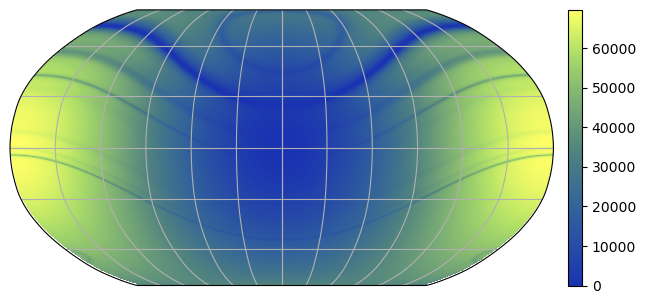

In [18]:

d25 = sh.SHMagCoeffs.from_file('../crustal_field_model/PINN2025.sh')
d25 = d25.change_ref(3393.5e3+150e3)

coeffs_rotation = d25.coeffs.copy()
alphas = list(np.arange(0.1,360,0.1))
n = len(alphas)+1
for alpha in alphas:
    coeffs_rotation += d25.rotate(alpha,0,0).coeffs
coeffs_rotation /= n
coeffs_rotation = sh.SHMagCoeffs.from_array(coeffs_rotation,r0=d25.r0)

# # season = 'summer' # 'summer', 'winter', 'spring', 'autumn' or None
# if season == 'summer':
coeffs_rotation = coeffs_rotation.rotate(0,25,0)
# elif season == 'winter':
#     coeffs_rotation = coeffs_rotation.rotate(0,-25,0)
# elif season == 'autumn':
#     coeffs_rotation = coeffs_rotation.rotate(0,-25,-90, convention='x')
# elif season == 'spring':
#     coeffs_rotation = coeffs_rotation.rotate(0,-25,90, convention='x')
# elif season == None:
#     season = ''
# if season is not None:
#     season = '_'+season

expansion_rotation = coeffs_rotation.expand()
total_field = expansion_rotation.total


latitudes = np.linspace(-90,90,281 )
longitudes = np.linspace(0,360,561)
_, latitudes = np.meshgrid(longitudes,latitudes)
colat_rad = np.deg2rad(90-latitudes)
lon_rad = np.deg2rad(longitudes)

n_max = 7*1e4
n = ((np.sin(colat_rad)*np.cos(lon_rad) * n_max) + n_max)/2

grid_final = total_field.data* n/(total_field.data+1/total_field.data )
print("Max field (nT):", np.max(grid_final))
print("Min field (nT):", np.min(grid_final))
grid_final = sh.SHGrid.from_array(grid_final,grid='DH')
fig, ax = grid_final.plot(projection=ccrs.Robinson(central_longitude=180),
                                # cmap_scale='log', 
                                # cmap=cm.lajolla, 
                                cmap=cm.imola, 
                                cmap_reverse=False,
                                grid=True,
                                # tick_interval=[90,30],
                                cmap_limits=[0,69628],
                                colorbar='right',
)




### compute rotation avg of B crust

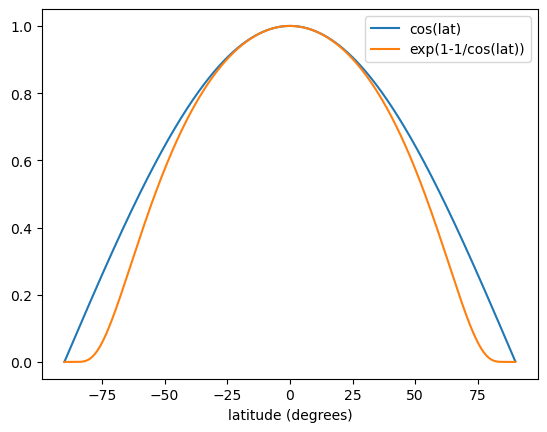

In [3]:
lat = np.arange(-90,90,0.1)
lat = np.deg2rad(lat)
plt.plot(np.rad2deg(lat),np.cos(lat), label='cos(lat)')
# plt.plot(lat,np.sqrt(np.cos(lat)),label='sqrt(cos(lat))')
plt.plot(np.rad2deg(lat), np.exp(1-1/np.cos(lat)), label='exp(1-1/cos(lat))')
plt.xlabel('latitude (degrees)')

plt.legend()


C:\Users\Timothee Delcourt\AppData\Local\Temp\ipykernel_18904\1496583210.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(b, b+1/(b))


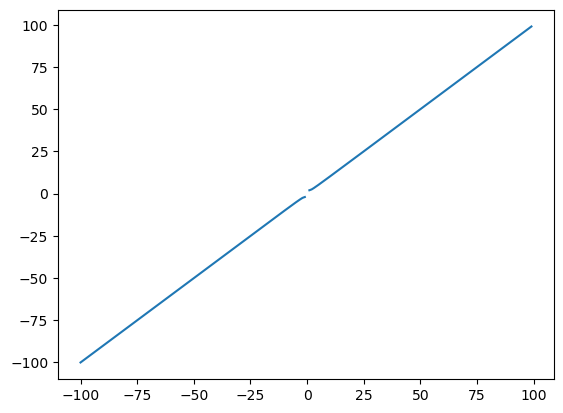

In [255]:
b = np.arange(-100,100,1)
plt.plot(b, b+1/(b))

In [11]:
def plot_rotation_avg(season=None, savefig=False, savecoeffs=False):

    d25 = sh.SHMagCoeffs.from_file('../crustal_field_model/PINN2025.sh')
    d25 = d25.change_ref(3393.5e3+150e3)
    # expansion = d25.expand()
    # # colorbar scale = log
    # expansion.plot_total(projection=ccrs.Robinson(central_longitude=180),
    #                     cmap_scale='log', 
    #                     cmap=cm.lajolla, 
    #                     cmap_reverse=True, 
    #                     cmap_limits=[1e-1,1e3],
    #                     grid=False,
    #                     tick_interval=[60,30],
    #                     xlabel='Longitude (degrees)',
    #                     ylabel='Latitude (degrees)',
    # )

    coeffs_rotation = d25.coeffs.copy()
    alphas = list(np.arange(0.1,360,0.1))
    n = len(alphas)+1
    for alpha in alphas:
        coeffs_rotation += d25.rotate(alpha,0,0).coeffs
    coeffs_rotation /= n
    coeffs_rotation = sh.SHMagCoeffs.from_array(coeffs_rotation,r0=d25.r0)

    # season = 'summer' # 'summer', 'winter', 'spring', 'autumn' or None
    if season == 'summer':
        coeffs_rotation = coeffs_rotation.rotate(0,25,0)
    elif season == 'winter':
        coeffs_rotation = coeffs_rotation.rotate(0,-25,0)
    elif season == 'autumn':
        coeffs_rotation = coeffs_rotation.rotate(0,-25,-90, convention='x')
    elif season == 'spring':
        coeffs_rotation = coeffs_rotation.rotate(0,-25,90, convention='x')
    elif season == None:
        season = ''
    if season is not None:
        season = '_'+season

    if savecoeffs:
        coeffs_rotation.to_file(f'../crustal_field_model/PINN2025_rotation_avg{season}.sh') # bug, winter -> summer

    expansion_rotation = coeffs_rotation.expand()
    total_field = expansion_rotation.total
    print(f'Max field rotation avg {season} (nT):', np.max(total_field.data))
    # multiply by np.exp(-1/cos_lat) to account for the ionospheric currents being stronger at the equator
    # total field is a Driscoll and Healy (1994) sampled grids. So latitudes are equally spaced from -90 to 90
    latitudes = np.linspace(-90,90,281 )
    _, latitudes = np.meshgrid(np.linspace(0,360,561),latitudes)
    cos_lat = np.cos(np.deg2rad(latitudes))
    factor = np.exp(1-1/cos_lat)
    grid_final = total_field.data * factor
    grid_final = sh.SHGrid.from_array(grid_final,grid='DH')
    fig, ax = grid_final.plot(projection=ccrs.Robinson(central_longitude=180),
                                    cmap_scale='log', 
                                    # cmap=cm.lajolla, 
                                    cmap=cm.imola, 
                                    cmap_reverse=False,
                                    # grid=True,
                                    # tick_interval=[90,30],
                                    cmap_limits=[1e-1,1e2],
                                    # colorbar='bottom',
    )
    if savefig:
        fig.savefig(f'../figures/rotation_avg/crustal_field_rotation_avg{season}_chapmanprod.pdf',dpi=300)
        plt.close()
    else:
        plt.show()
    

    

Max field rotation avg _spring (nT): 76.16712653852275


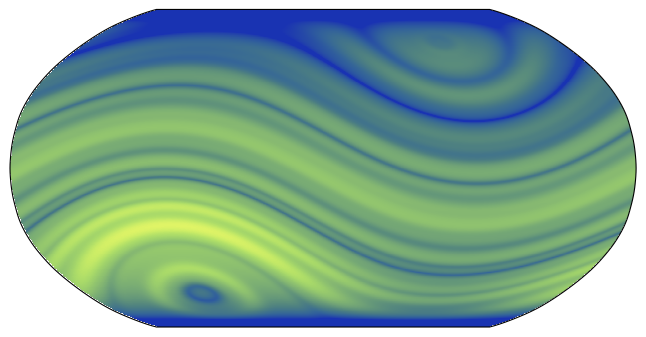

In [12]:
plot_rotation_avg('spring', savefig=False, savecoeffs=False)

In [15]:
# plot_rotation_avg('summer')

for season in ['spring', 'autumn', None, 'summer', 'winter']:
    plot_rotation_avg(season, savefig=True, savecoeffs=False)

### playground

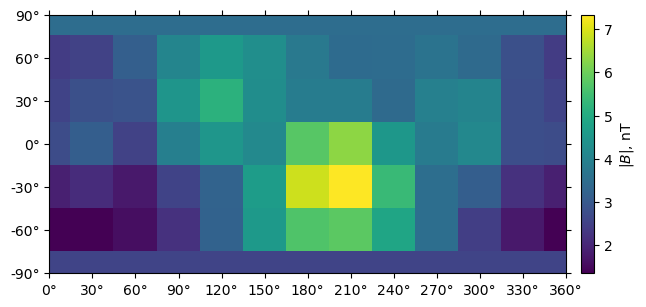

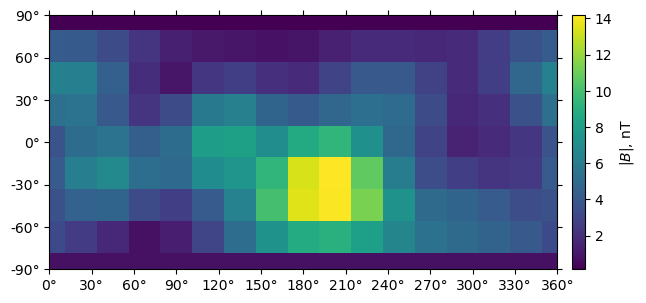

Error in callback <function flush_figures at 0x000001A39FB05940> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [16]:
l_list = list(range(2, 20))
l_list.append(134)
for l in l_list:
    l19 = sh.datasets.Mars.Langlais2019(lmax=l)
    expansion = l19.expand()
    expansion.plot_total()